In [18]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from tqdm import tqdm
import awkward as ak
import plotly.graph_objs as go
import plotly.express as px
from particle_utils import get_name_from_pdgc
from scipy.optimize import fmin

In [19]:
data = uproot.open("../build/double-height-onlyMuons.root:Hits")
# sps = uproot.open("../build/test.root:spacePoints")
events = data.arrays(data.keys(), library="ak")
# space_points = sps.arrays(sps.keys(), library="ak")

In [22]:

def vis_tracks(event):
    
    lines = []
    scatter = []
    
    print(event['fEvent'])
    
    print(len(event.x.tolist()))

    scatter.append(go.Scatter3d( x=event.x.tolist(), y=event.y.tolist(), z=event.z.tolist(),
        mode='markers', 
        marker=dict(
        size=1,
        color="black",
        opacity=1)))
    
    # scatter.append(go.Scatter3d( x=event.true_x.tolist(), y=event.true_y.tolist(), z=event.true_z.tolist(),
    #     mode='markers', 
    #     marker=dict(
    #     size=1,
    #     color="orange",
    #     opacity=1)))
    
    
    data = zip(event.x.tolist(), event.y.tolist(), event.z.tolist())
    data = np.array(list(data))
    
    data_mean = np.mean(data, axis=0)

    # Perform Singular Value Decomposition (SVD)
    _, _, vh = np.linalg.svd(data - data_mean)

    # The direction vector of the best-fit line
    direction = vh[0]

    # Generate points along the best-fit line for visualization
    t = np.linspace(-1000, 1000, 100)
    line_points = data_mean + t[:, np.newaxis] * direction

    lx = line_points[:, 0]
    ly = line_points[:, 1]
    lz = line_points[:, 2]

    lines.append(go.Scatter3d( x=lx, y=ly, z=lz, mode='lines', line=dict(color='red', width=1)))            
    # print(len(ak.flatten(space_points.x).tolist()))
    # scatter.append(go.Scatter3d( x=ak.flatten(space_points.x).tolist(), y=ak.flatten(space_points.y).tolist(), z=ak.flatten(space_points.z).tolist(),
    #     mode='markers',
    #     marker=dict(
    #     size=1,
    #     color="purple",
    #     opacity=1)))

    
    # Create the 3D scatter plot
    # fig = go.Figure(lines)
    fig = go.Figure(data=lines+scatter)
    # Customize the layout
    fig.update_layout(
        title="",
        scene=dict(
            xaxis_title='X Axis',
            yaxis_title='Y Axis',
            zaxis_title='Z Axis'
        ),
        width=1200, # Set the width here 
        height=800 # Set the height here
    )

    # Show the plot in the notebook
    fig.show()


In [58]:
vis_tracks(events[events['fEvent'].to_list().index(39382060)])

39382060
82


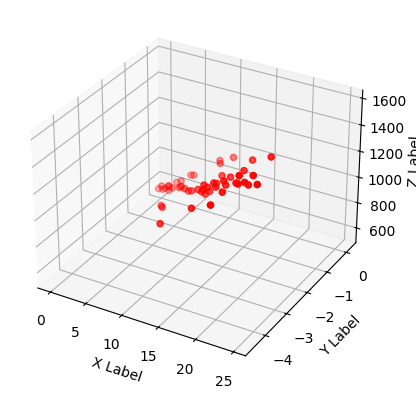

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generate random data for the scatter plot
x = events[0].x
y = events[0].y
z = events[0].z

# tx = events[0].true_x
# ty = events[0].true_y
# tz = events[0].true_z

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot
ax.scatter(x, y, z, c='r', marker='o')
# ax.scatter(tx, ty, tz, c='g', marker='o')

# Add labels to the axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# Show the plot
plt.show()

In [63]:
def line_to_hit_distance(u, line_anchor, line_dir, hit_pos):
    start_pos_x = line_anchor[0] + u * line_dir[0]
    start_pos_y = line_anchor[1] + u * line_dir[1]
    start_pos_z = line_anchor[2] + u * line_dir[2]
        
    distance = np.sqrt((start_pos_x - hit_pos[0])**2 + (start_pos_y - hit_pos[1])**2 +(start_pos_z - hit_pos[2])**2)
    
    return distance


cce_muon_ips = []
ccm_muon_ips = []
cct_muon_ips = []
nc_muon_ips = []
muon_ips_with_tau_hit = []

for evt_idx in tqdm(range(len(events['vertex_x']))):
    
    muon_ip = -999
    
    smallest_z = 1e9
    
    vertex_x = events['vertex_x'][evt_idx]
    vertex_y = events['vertex_y'][evt_idx]
    vertex_z = events['vertex_z'][evt_idx]
    vertex = [vertex_x, vertex_y, vertex_z]
    
    if len(events[evt_idx].x.tolist()) == 0: continue
    if len(events[evt_idx].x.tolist()) > 50: continue
    
    data = zip(events[evt_idx].x.tolist(), events[evt_idx].y.tolist(), events[evt_idx].z.tolist())
    data = np.array(list(data))
    
    data_mean = np.mean(data, axis=0)

    # Perform Singular Value Decomposition (SVD)
    _, _, vh = np.linalg.svd(data - data_mean)

    # The direction vector of the best-fit line
    direction = vh[0]

    # Generate points along the best-fit line for visualization
    t = np.linspace(-1000, 1000, 100)
    line_points = data_mean + t[:, np.newaxis] * direction

    lx = line_points[:, 0]
    ly = line_points[:, 1]
    lz = line_points[:, 2]
    
            
    track_length = np.sqrt((lx[0] - lx[-1])**2 + (ly[0] - ly[-1])**2 + (lz[0] - lz[-1])**2)
        
    results = fmin(line_to_hit_distance, track_length, args=([lx[0], ly[0], lz[0]], direction, vertex), disp=False, full_output=True)
    track_to_vtx_distance = results[1]
    
    muon_ip = track_to_vtx_distance
        
    if events['isCC'][evt_idx] and abs(events['nu_pdgc'][evt_idx]) == 12: cce_muon_ips.append(muon_ip)
    elif events['isCC'][evt_idx] and abs(events['nu_pdgc'][evt_idx]) == 14: ccm_muon_ips.append(muon_ip)
    elif events['isCC'][evt_idx] and abs(events['nu_pdgc'][evt_idx]) == 16: cct_muon_ips.append(muon_ip)
    elif not events['isCC'][evt_idx]: nc_muon_ips.append(muon_ip)
            

100%|██████████| 371773/371773 [11:19<00:00, 546.76it/s]


cce_muon_ips =  770
ccm_muon_ips =  236282
cct_muon_ips =  238
nc_muon_ips =  1544


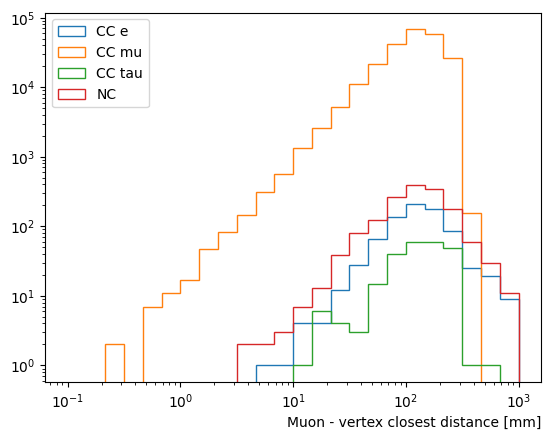

In [64]:
fig, ax = plt.subplots()
print("cce_muon_ips = ", len(cce_muon_ips))
print("ccm_muon_ips = ", len(ccm_muon_ips))
print("cct_muon_ips = ", len(cct_muon_ips))
print("nc_muon_ips = ", len(nc_muon_ips,))
density=False
ax.hist(cce_muon_ips, bins=np.logspace(-1, 3, 25), label='CC e', histtype='step', density=density)
ax.hist(ccm_muon_ips, bins=np.logspace(-1, 3, 25), label='CC mu', histtype='step', density=density)
ax.hist(cct_muon_ips, bins=np.logspace(-1, 3, 25), label='CC tau', histtype='step', density=density)
ax.hist(nc_muon_ips,  bins=np.logspace(-1, 3, 25), label='NC', histtype='step', density=density)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Muon - vertex closest distance [mm]", loc='right')
ax.legend()
plt.savefig("MuonIPs.pdf")

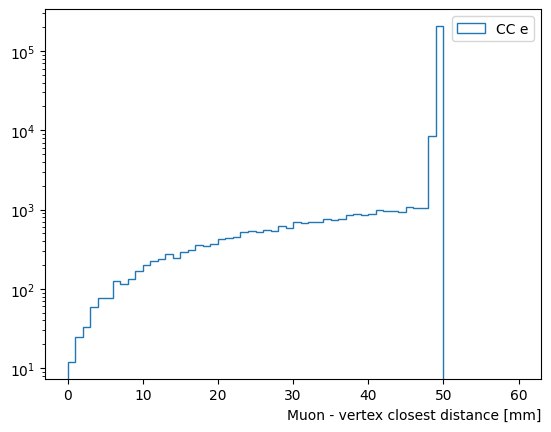

In [50]:
fig, ax = plt.subplots()
density=False
ax.hist([np.max(x) for x in events.layer if len(x) > 0], bins=np.linspace(0, 60, 61), label='CC e', histtype='step', density=density)
# ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Muon - vertex closest distance [mm]", loc='right')
ax.legend()


In [51]:
for x, n in zip(events.x, events.fEvent):
    if len(x) == 0: continue
    if len(x) < 50: continue
    print(len(x), n)

50 24803429
50 93835252
50 82601953
50 99354776
50 24889810
50 30685750
58 28606484
70 18062193
50 45507590
72 87699994
50 71184654
50 11748579
50 86503916
54 82510978
62 58869566
57 81906108
64 69018774
50 60918214
50 20601787
50 69399213
60 97975711
50 56036298
50 60417255
50 34677213
50 31167016
50 17113257
85 33028957
50 97027152
56 55417905
54 19918628
50 31383395
50 21634620
51 67229777
50 45774963
83 41106437
50 55230327
50 91455454
67 39437036
50 32179949
50 57730598
50 24745593
50 60958763
64 83900548
51 53407256
52 28799949
80 77813135
50 90034146
50 29205999
57 59100398
69 39999104
50 15185597
54 74966880
53 77827364
50 11627372
50 43245629
50 88960330
50 35833413
50 17323844
50 63379145
124 76868876
50 43085884
68 15745150
71 31421314
50 33764303
50 56777791
50 79948888
62 12813641
50 36140985
50 42354386
50 33061166
50 69546973
50 56218755
50 21136667
50 93321920
50 84317734
50 19338875
56 37951293
50 65218914
50 84599656
60 81030654
50 76255836
50 35016223
50 57008293
50 